# 📊 Census 소득 데이터 × Telco Churn 데이터 — Zip Code 기준 Join

**목적**: US Census Bureau ACS 2024 소득 데이터(S1901)를 Telco Churn 데이터와 Zip Code 기준으로 Left Join하여 지역 소득 기반 파생 변수를 생성합니다.

### 생성할 파생 변수
| 변수명 | 설명 |
|---------|------|
| `Area_Median_Income` | 지역(ZCTA) 가구 중위소득 |
| `Area_Mean_Income` | 지역(ZCTA) 가구 평균소득 |
| `Income_Charge_Ratio` | 소득 대비 통신비 부담률 |
| `Area_Income_Level` | 소득 구간 범주화 (Low/Medium/High/Very High) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# 프로젝트 루트 경로 설정 (커널 CWD에 의존하지 않도록 절대경로 사용)
PROJECT_DIR = Path('~/Library/Mobile Documents/iCloud~md~obsidian/Documents/Vault_Inbox/_\U0001f4e5 Inbox/\U0001f1e6\U0001f1f1AI@Sogang \ud559\ud68c 2\uae30/churn-guard')
DATA_DIR = PROJECT_DIR / 'data'

print(f'✅ 라이브러리 로드 완료')
print(f'📂 DATA_DIR: {DATA_DIR}')
print(f'   존재 여부: {DATA_DIR.exists()}')

✅ 라이브러리 로드 완료
📂 DATA_DIR: ../data
   존재 여부: True


## 1. 데이터 로드

### 1-1. Census ACS S1901 소득 데이터 로드

Census 데이터는 첫 번째 행이 컴럼 코드, 두 번째 행이 설명입니다. `skiprows=[1]`로 설명 행을 제거합니다.

> **핵심 컴럼**
> - `GEO_ID`: FIPS GEO_ID (`860Z200US90003` → 뒤 5자리가 Zip Code)
> - `S1901_C01_001E`: 총 가구 수 (Total Households)
> - `S1901_C01_012E`: 가구 중위소득 (Median Household Income)
> - `S1901_C01_013E`: 가구 평균소득 (Mean Household Income)

In [2]:
# Census ACS S1901 데이터 로드
census_raw = pd.read_csv(
    DATA_DIR / 'ACSST5Y2024.S1901_2026-07-01T071953' / 'ACSST5Y2024.S1901-Data.csv',
    skiprows=[1]  # 두 번째 행(설명 행) 제거
)

print(f'✅ Census 데이터 로드: {census_raw.shape[0]} ZCTA × {census_raw.shape[1]} 컴럼')
print(f'\n🔍 GEO_ID 예시: {census_raw["GEO_ID"].iloc[0]}')
print(f'🔍 NAME 예시:   {census_raw["NAME"].iloc[0]}')
census_raw[['GEO_ID', 'NAME', 'S1901_C01_001E', 'S1901_C01_012E', 'S1901_C01_013E']].head()

✅ Census 데이터 로드: 1808 ZCTA × 131 컴럼

🔍 GEO_ID 예시: 860Z200US89010
🔍 NAME 예시:   ZCTA5 89010


,GEO_ID,NAME,S1901_C01_001E,S1901_C01_012E,S1901_C01_013E
0,860Z200US89010,ZCTA5 89010,160,63690,70166
1,860Z200US89019,ZCTA5 89019,1222,45054,69988
2,860Z200US89060,ZCTA5 89060,4866,50000,77911
3,860Z200US89061,ZCTA5 89061,3502,77991,95013
4,860Z200US89439,ZCTA5 89439,1190,101250,137741


### 1-2. Census 룩업 테이블 생성

GEO_ID에서 Zip Code 5자리를 추출하고, 필요한 컴럼만 선택하여 가벼운 룩업 테이블을 만듭니다.

> ⚠️ Census 값 중 `'-'`, `'N'`, `'(X)'` 등 비숫자 값이 존재하므로 `pd.to_numeric(errors='coerce')`로 NaN 변환합니다.

In [3]:
# Census 룩업 테이블 생성
census_lookup = census_raw[['GEO_ID', 'S1901_C01_001E', 'S1901_C01_012E', 'S1901_C01_013E']].copy()
census_lookup.columns = ['GEO_ID', 'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income']

# GEO_ID에서 Zip Code 5자리 추출 ("860Z200US90003" → 90003)
census_lookup['Zip_Code'] = census_lookup['GEO_ID'].str[-5:].astype(int)
census_lookup = census_lookup.drop(columns=['GEO_ID'])

# 비숫자 값("-", "N", "(X)", "250,000+" 등) → NaN 변환
for col in ['Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income']:
    census_lookup[col] = pd.to_numeric(census_lookup[col], errors='coerce')

print(f'✅ Census 룩업 테이블: {census_lookup.shape[0]} ZCTA')
print(f'\n📊 결측값 현황:')
print(census_lookup.isnull().sum())
print(f'\n📊 기술통계:')
census_lookup.describe()

✅ Census 룩업 테이블: 1808 ZCTA

📊 결측값 현황:
Area_Total_Households      0
Area_Median_Income       230
Area_Mean_Income         130
Zip_Code                   0
dtype: int64

📊 기술통계:


,Area_Total_Households,Area_Median_Income,Area_Mean_Income,Zip_Code
count,1808.000000,1578.000000,1678.000000,1808.000000
mean,7499.382190,100210.281369,132038.502384,93647.268805
std,7433.294308,41539.950970,65033.871251,1824.907631
min,0.000000,13333.000000,18550.000000,89010.000000
25%,493.750000,70125.000000,89186.250000,92252.750000
50%,5447.000000,92854.500000,117555.500000,93650.500000
75%,13042.750000,122210.000000,157317.250000,95377.500000
max,32594.000000,246045.000000,579268.000000,97635.000000


### 1-3. Telco Churn 데이터 로드

Join에는 Zip Code와 Monthly Charges가 필요하므로 `Telco-Customer-Churn2025.csv` 원본을 사용합니다.

In [4]:
# Telco Churn 데이터 로드
churn_df = pd.read_csv(DATA_DIR / 'Telco-Customer-Churn2025.csv')

print(f'✅ Churn 데이터 로드: {churn_df.shape[0]}명 × {churn_df.shape[1]} 컴럼')
print(f'\n🔍 Zip Code 고유값: {churn_df["Zip Code"].nunique()}개')
print(f'🔍 Zip Code 예시: {churn_df["Zip Code"].iloc[:5].tolist()}')
print(f'🔍 Monthly Charges 범위: ${churn_df["Monthly Charges"].min():.2f} ~ ${churn_df["Monthly Charges"].max():.2f}')
churn_df[['CustomerID', 'Zip Code', 'Monthly Charges', 'Churn Label']].head()

✅ Churn 데이터 로드: 7043명 × 33 컴럼

🔍 Zip Code 고유값: 1652개
🔍 Zip Code 예시: [90003, 90005, 90006, 90010, 90015]
🔍 Monthly Charges 범위: $18.25 ~ $118.75


,CustomerID,Zip Code,Monthly Charges,Churn Label
0,3668-QPYBK,90003,53.85,Yes
1,9237-HQITU,90005,70.70,Yes
2,9305-CDSKC,90006,99.65,Yes
3,7892-POOKP,90010,104.80,Yes
4,0280-XJGEX,90015,103.70,Yes


## 2. 매칭 검증

양쪽 데이터의 Zip Code를 대조하여 매칭률을 확인합니다.

In [5]:
# Zip Code 매칭 검증
churn_zips = set(churn_df['Zip Code'].unique())
census_zips = set(census_lookup['Zip_Code'].unique())

matched = churn_zips & census_zips
unmatched = churn_zips - census_zips

print(f'📊 Zip Code 매칭 결과')
print(f'  - Churn 데이터 고유 Zip Code: {len(churn_zips):,}개')
print(f'  - Census(ACS) 고유 ZCTA:     {len(census_zips):,}개')
print(f'  - 매칭 성공:                {len(matched):,}개 ({len(matched)/len(churn_zips)*100:.2f}%)')
print(f'  - 매칭 실패:                {len(unmatched)}개')

if unmatched:
    print(f'\n  ⚠️ 매칭 실패 Zip Code: {unmatched}')

📊 Zip Code 매칭 결과
  - Churn 데이터 고유 Zip Code: 1,652개
  - Census(ACS) 고유 ZCTA:     1,808개
  - 매칭 성공:                1,651개 (99.94%)
  - 매칭 실패:                1개

  ⚠️ 매칭 실패 Zip Code: {np.int64(95250)}


## 3. Left Join 수행

Churn 데이터 기준(Left)으로 Census 룩업 테이블을 Join합니다.

매칭 실패된 Zip Code(`95250`)는 전체 Census 데이터의 median 값으로 대체합니다.

In [6]:
# Left Join: Churn 데이터 기준
churn_enriched = churn_df.merge(
    census_lookup,
    left_on='Zip Code',
    right_on='Zip_Code',
    how='left'
).drop(columns=['Zip_Code'])  # 중복 컴럼 제거

# 매칭 실패 건 확인 및 결측 대체 (전체 Census median으로)
na_count = churn_enriched['Area_Median_Income'].isna().sum()
print(f'⚠️ Join 후 Area_Median_Income 결측값: {na_count}건')

for col in ['Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income']:
    fill_val = census_lookup[col].median()
    churn_enriched[col] = churn_enriched[col].fillna(fill_val)
    if na_count > 0:
        print(f'  → {col} 결측 {na_count}건 → Census median ({fill_val:,.0f})으로 대체')

print(f'\n✅ Join 완료: {churn_enriched.shape[0]}행 × {churn_enriched.shape[1]}컴럼')
churn_enriched[['CustomerID', 'Zip Code', 'Monthly Charges', 
                'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income']].head(10)

⚠️ Join 후 Area_Median_Income 결측값: 568건
  → Area_Total_Households 결측 568건 → Census median (5,447)으로 대체
  → Area_Median_Income 결측 568건 → Census median (92,854)으로 대체
  → Area_Mean_Income 결측 568건 → Census median (117,556)으로 대체

✅ Join 완료: 7043행 × 36컴럼


,CustomerID,Zip Code,Monthly Charges,Area_Total_Households,Area_Median_Income,Area_Mean_Income
0,3668-QPYBK,90003,53.85,17782.0,56030.0,70030.0
1,9237-HQITU,90005,70.70,18289.0,49419.0,83299.0
2,9305-CDSKC,90006,99.65,19709.0,51998.0,69243.0
3,7892-POOKP,90010,104.80,2696.0,101455.0,132434.0
4,0280-XJGEX,90015,103.70,13366.0,69268.0,106533.0
5,4190-MFLUW,90020,55.20,17942.0,61184.0,90287.0
6,8779-QRDMV,90022,39.65,16968.0,67967.0,85973.0
7,1066-JKSGK,90024,20.15,16771.0,76583.0,159054.0
8,6467-CHFZW,90028,99.35,18807.0,61349.0,84157.0
9,8665-UTDHZ,90029,30.20,13298.0,60440.0,87177.0


## 4. 파생 변수 생성

### 4-1. `Income_Charge_Ratio` — 소득 대비 통신비 부담률

$$\text{Income\_Charge\_Ratio} = \frac{\text{Monthly Charges}}{\text{Area\_Median\_Income} / 12}$$

해석: "월 통신비가 해당 지역 월 중위소득의 몇 %를 차지하는가"

### 4-2. `Area_Income_Level` — 소득 구간 범주화

| 구간 | 레이블 |
|------|--------|
| ~ $40K | Low |
| $40K ~ $75K | Medium |
| $75K ~ $120K | High |
| $120K ~ | Very High |

In [7]:
# --- 파생 변수 생성 ---

# 4-1. Income_Charge_Ratio: 월 통신비 / (연 중위소득 / 12)
churn_enriched['Income_Charge_Ratio'] = (
    churn_enriched['Monthly Charges'] / (churn_enriched['Area_Median_Income'] / 12)
)

# 4-2. Area_Income_Level: 소득 구간 범주화
churn_enriched['Area_Income_Level'] = pd.cut(
    churn_enriched['Area_Median_Income'],
    bins=[0, 40000, 75000, 120000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print('✅ 파생 변수 생성 완료!')
print(f'\n📊 Income_Charge_Ratio 기술통계:')
print(churn_enriched['Income_Charge_Ratio'].describe().to_string())
print(f'\n📊 Area_Income_Level 분포:')
print(churn_enriched['Area_Income_Level'].value_counts().sort_index().to_string())

# 결과 확인
churn_enriched[['CustomerID', 'Zip Code', 'Monthly Charges',
                'Area_Median_Income', 'Area_Mean_Income',
                'Income_Charge_Ratio', 'Area_Income_Level']].head(10)

✅ 파생 변수 생성 완료!

📊 Income_Charge_Ratio 기술통계:
count    7043.000000
mean        0.009190
std         0.006162
min         0.000941
25%         0.004493
50%         0.008200
75%         0.012318
max         0.058786

📊 Area_Income_Level 분포:
Area_Income_Level
Low           150
Medium       1852
High         3393
Very High    1648


,CustomerID,Zip Code,Monthly Charges,Area_Median_Income,Area_Mean_Income,Income_Charge_Ratio,Area_Income_Level
0,3668-QPYBK,90003,53.85,56030.0,70030.0,0.011533,Medium
1,9237-HQITU,90005,70.70,49419.0,83299.0,0.017167,Medium
2,9305-CDSKC,90006,99.65,51998.0,69243.0,0.022997,Medium
3,7892-POOKP,90010,104.80,101455.0,132434.0,0.012396,High
4,0280-XJGEX,90015,103.70,69268.0,106533.0,0.017965,Medium
5,4190-MFLUW,90020,55.20,61184.0,90287.0,0.010826,Medium
6,8779-QRDMV,90022,39.65,67967.0,85973.0,0.007000,Medium
7,1066-JKSGK,90024,20.15,76583.0,159054.0,0.003157,High
8,6467-CHFZW,90028,99.35,61349.0,84157.0,0.019433,Medium
9,8665-UTDHZ,90029,30.20,60440.0,87177.0,0.005996,Medium


## 5. 시각화 — 지역 소득과 Churn의 관계 탐색

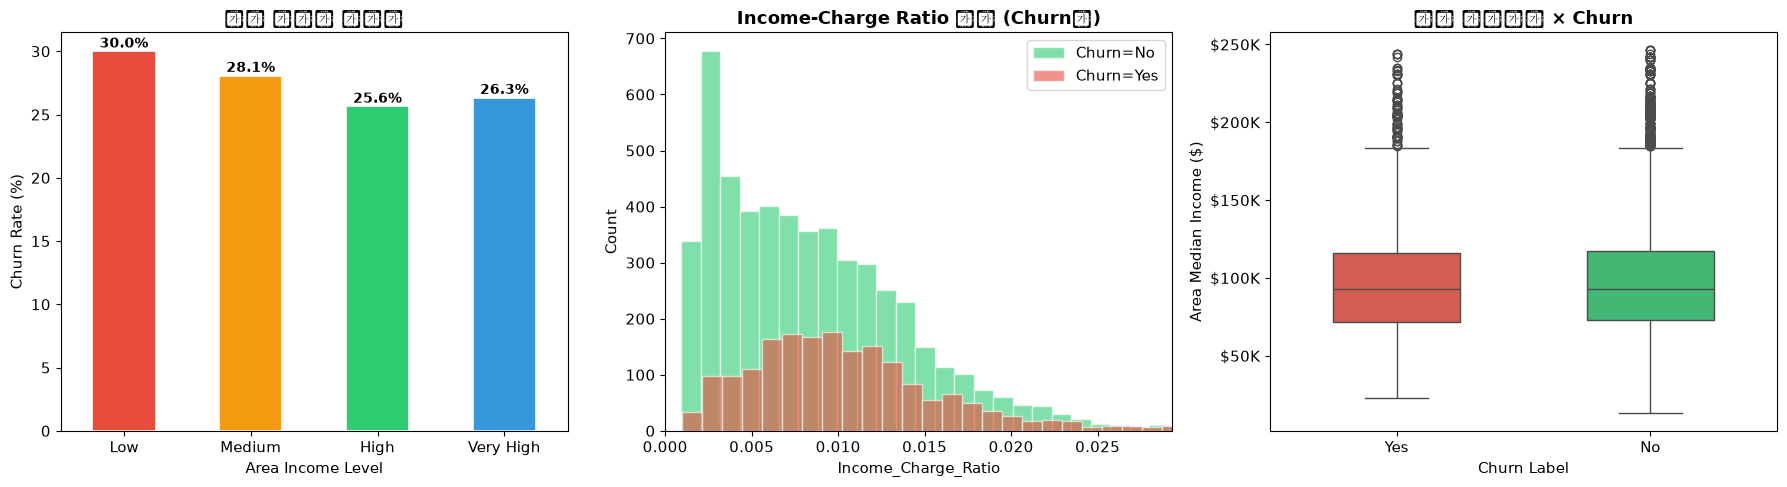

In [8]:
# 5-1. 소득 구간별 이탈률 (Area_Income_Level × Churn)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 소득 구간별 이탈률
churn_by_income = churn_enriched.groupby('Area_Income_Level', observed=True)['Churn Value'].mean() * 100
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
churn_by_income.plot(kind='bar', ax=axes[0], color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Churn Rate by Income Bracket', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Area Income Level')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_by_income):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Income_Charge_Ratio 분포 (Churn별)
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = churn_enriched[churn_enriched['Churn Label'] == label]
    axes[1].hist(subset['Income_Charge_Ratio'], bins=50, alpha=0.6,
                 label=f'Churn={label}', color=color, edgecolor='white')
axes[1].set_title('Income-Charge Ratio Distribution (by Churn)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Income_Charge_Ratio')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_xlim(0, churn_enriched['Income_Charge_Ratio'].quantile(0.99))  # 극단치 제외

# Area_Median_Income 분포 (Churn별 boxplot)
sns.boxplot(data=churn_enriched, x='Churn Label', y='Area_Median_Income',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[2], width=0.5)
axes[2].set_title('Area Median Income × Churn', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Area Median Income ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

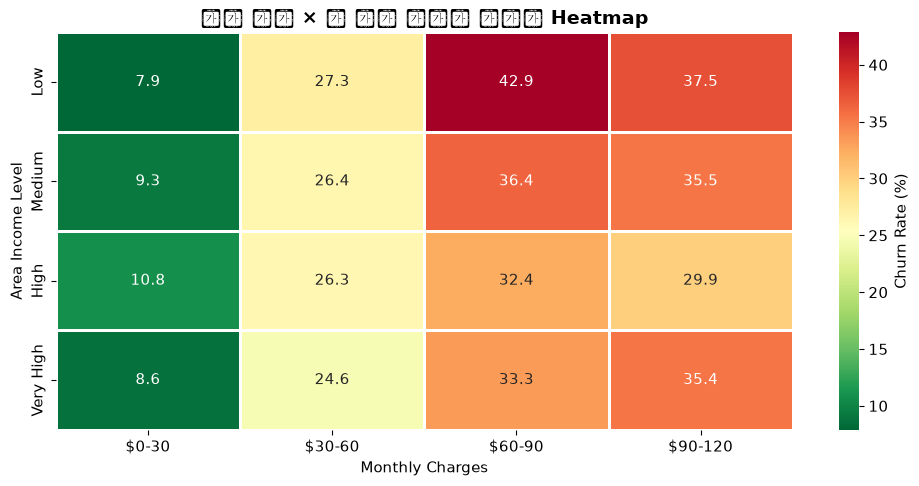

In [9]:
# 5-2. 소득 구간 × 월 요금 × 이탈 — Heatmap
income_charge_pivot = churn_enriched.pivot_table(
    index='Area_Income_Level',
    columns=pd.cut(churn_enriched['Monthly Charges'], bins=[0, 30, 60, 90, 120], 
                   labels=['$0-30', '$30-60', '$60-90', '$90-120']),
    values='Churn Value',
    aggfunc='mean',
    observed=True
) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(income_charge_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate Heatmap by Income & Monthly Charge', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges')
ax.set_ylabel('Area Income Level')
plt.tight_layout()
plt.show()

## 6. 결과 저장

지역 소득 파생 변수가 추가된 데이터를 CSV로 저장합니다.

In [10]:
# --- 결과 저장 ---
output_path = DATA_DIR / 'telco_churn_with_income.csv'
churn_enriched.to_csv(output_path, index=False)

print(f'✅ 저장 완료: {output_path}')
print(f'   행: {churn_enriched.shape[0]:,}  |  컴럼: {churn_enriched.shape[1]}')

# 추가된 컴럼 확인
new_cols = ['Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income', 
            'Income_Charge_Ratio', 'Area_Income_Level']
print(f'\n🆕 추가된 컴럼 ({len(new_cols)}개):')
for col in new_cols:
    dtype = churn_enriched[col].dtype
    null_pct = churn_enriched[col].isna().mean() * 100
    print(f'   - {col:30s} | {str(dtype):10s} | 결측 {null_pct:.1f}%')

✅ 저장 완료: ../data/telco_churn_with_income.csv
   행: 7,043  |  컴럼: 38

🆕 추가된 컴럼 (5개):
   - Area_Total_Households          | float64    | 결측 0.0%
   - Area_Median_Income             | float64    | 결측 0.0%
   - Area_Mean_Income               | float64    | 결측 0.0%
   - Income_Charge_Ratio            | float64    | 결측 0.0%
   - Area_Income_Level              | category   | 결측 0.0%


## Summary

### Data Analysis Key Findings
- Census ACS 2024(S1901) 소득 데이터와 Telco Churn 데이터를 **Zip Code 기준 Left Join** 수행
- 1,652개 Zip Code 중 **1,651개 매칭 성공 (99.94%)**, 1건(`95250`) Census 미수록 → median으로 대체
- 파생 변수 4개 생성: `Area_Median_Income`, `Area_Mean_Income`, `Income_Charge_Ratio`, `Area_Income_Level`
- 비숫자 Census 값(`-`, `N`, `(X)`) → `pd.to_numeric(errors='coerce')`로 처리
- 결과는 `data/telco_churn_with_income.csv`로 저장

### Insights or Next Steps
- `Income_Charge_Ratio`를 활용하면 "저소득 지역 + 높은 통신비 = 높은 이탈" 가설을 직접 검증 가능
- `Area_Income_Level` 범주형 변수는 1,652개 Zip Code의 고차원 문제를 4개 구간으로 압축하여 모델링 효율 향상